# MNIST Binary Classification - Decision Tree

## Complete Pipeline: Data Loading → Preprocessing → Training → Evaluation

This notebook contains the complete end-to-end pipeline for Decision Tree.

## 1. Import Libraries

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Configuration

In [2]:
# Binary classification configuration
DIGIT_A = 0
DIGIT_B = 1

# Data split configuration
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# PCA configuration
PCA_COMPONENTS = 50

# Decision Tree hyperparameters
MAX_DEPTH = 10
MIN_SAMPLES_SPLIT = 2

print(f"Configuration:")
print(f"  Binary Classification: Digit {DIGIT_A} vs Digit {DIGIT_B}")
print(f"  Train/Val/Test Split: {TRAIN_SIZE:.0%}/{VAL_SIZE:.0%}/{TEST_SIZE:.0%}")
print(f"  PCA Components: {PCA_COMPONENTS}")
print(f"  Max Depth: {MAX_DEPTH}")
print(f"  Min Samples Split: {MIN_SAMPLES_SPLIT}")

Configuration:
  Binary Classification: Digit 0 vs Digit 1
  Train/Val/Test Split: 70%/15%/15%
  PCA Components: 50
  Max Depth: 10
  Min Samples Split: 2


## 3. Load MNIST Dataset

In [3]:
print("=" * 70)
print("LOADING DATA")
print("=" * 70)

# Load training data from .npy files
X_train_raw = np.load('../mnist.npz/x_train.npy')
y_train_raw = np.load('../mnist.npz/y_train.npy')

# Load test data from .npy files
X_test_raw = np.load('../mnist.npz/x_test.npy')
y_test_raw = np.load('../mnist.npz/y_test.npy')

print(f"Training data shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"Test data shape: X={X_test_raw.shape}, y={y_test_raw.shape}")
print("\n✓ Data loaded successfully")

LOADING DATA
Training data shape: X=(60000, 28, 28), y=(60000,)
Test data shape: X=(10000, 28, 28), y=(10000,)

✓ Data loaded successfully


## 4. Visualize Sample MNIST Images

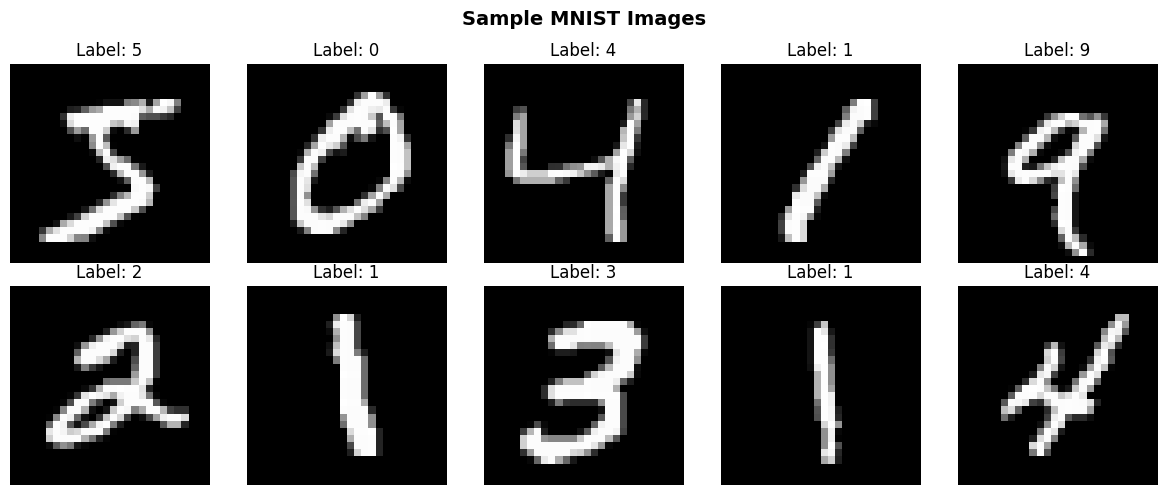

In [4]:
# Display sample images from the dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train_raw[i], cmap='gray')
    axes[i].set_title(f'Label: {y_train_raw[i]}')
    axes[i].axis('off')

plt.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Filter Binary Classes

In [5]:
print("=" * 70)
print(f"FILTERING BINARY CLASSES: {DIGIT_A} vs {DIGIT_B}")
print("=" * 70)

# Filter training data for selected digits
train_mask = (y_train_raw == DIGIT_A) | (y_train_raw == DIGIT_B)
X_train_filtered = X_train_raw[train_mask]
y_train_filtered = y_train_raw[train_mask]

# Filter test data for selected digits
test_mask = (y_test_raw == DIGIT_A) | (y_test_raw == DIGIT_B)
X_test_filtered = X_test_raw[test_mask]
y_test_filtered = y_test_raw[test_mask]

# Convert labels to binary (0 and 1)
y_train_binary = (y_train_filtered == DIGIT_B).astype(int)
y_test_binary = (y_test_filtered == DIGIT_B).astype(int)

print(f"Filtered training dataset size: {len(X_train_filtered)}")
print(f"Class distribution: {DIGIT_A}={np.sum(y_train_binary == 0)}, {DIGIT_B}={np.sum(y_train_binary == 1)}")
print("\n✓ Binary classes filtered")

FILTERING BINARY CLASSES: 0 vs 1
Filtered training dataset size: 12665
Class distribution: 0=5923, 1=6742

✓ Binary classes filtered


## Visualise Binary Classes

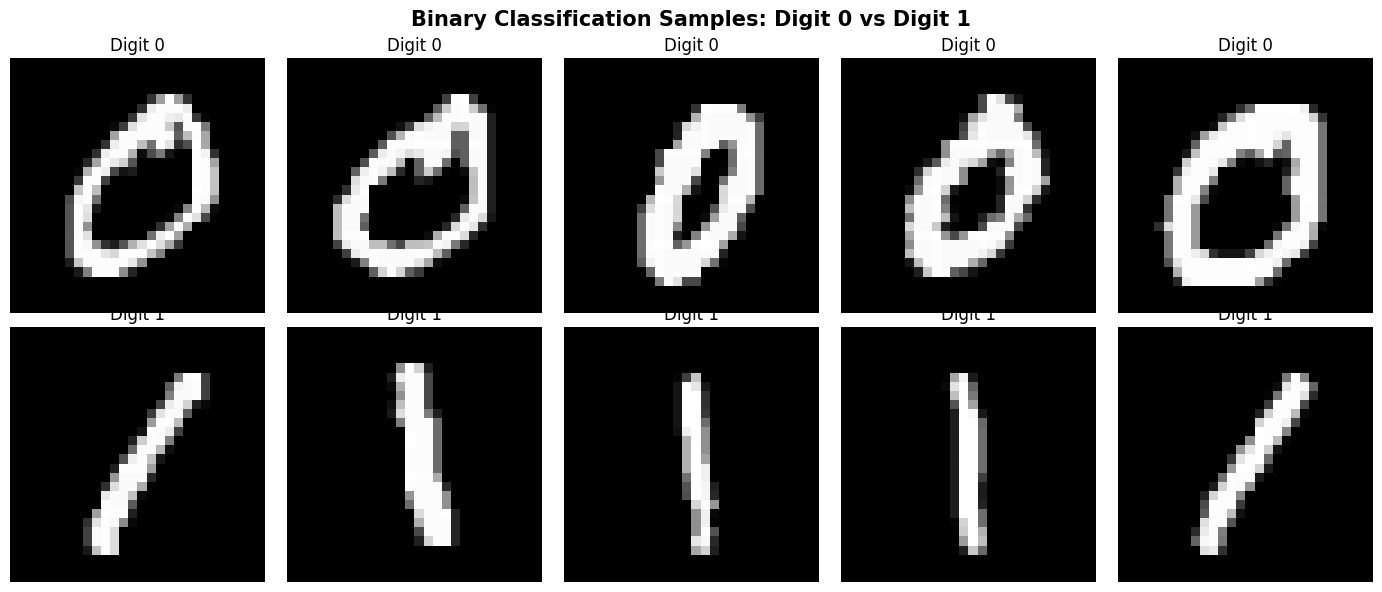

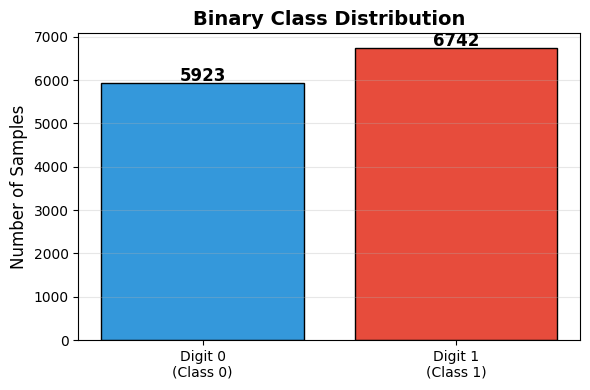

In [6]:
# ── Visualise the two binary classes chosen from the dataset ──────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

class0_idx = np.where(y_train_binary == 0)[0]
class1_idx = np.where(y_train_binary == 1)[0]

for i in range(5):
    axes[0, i].imshow(X_train_filtered[class0_idx[i]], cmap='gray')
    axes[0, i].set_title(f'Digit {DIGIT_A}', fontsize=12)
    axes[0, i].axis('off')

for i in range(5):
    axes[1, i].imshow(X_train_filtered[class1_idx[i]], cmap='gray')
    axes[1, i].set_title(f'Digit {DIGIT_B}', fontsize=12)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel(f'Class 0\n(Digit {DIGIT_A})', fontsize=12,
                       rotation=0, labelpad=60, va='center')
axes[1, 0].set_ylabel(f'Class 1\n(Digit {DIGIT_B})', fontsize=12,
                       rotation=0, labelpad=60, va='center')

plt.suptitle(f'Binary Classification Samples: Digit {DIGIT_A} vs Digit {DIGIT_B}',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Class-distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
counts = [np.sum(y_train_binary == 0), np.sum(y_train_binary == 1)]
bars = ax.bar([f'Digit {DIGIT_A}\n(Class 0)', f'Digit {DIGIT_B}\n(Class 1)'],
              counts, color=['#3498db', '#e74c3c'], edgecolor='black')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            str(c), ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Binary Class Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Image Normalization

In [7]:
print("=" * 70)
print("IMAGE NORMALIZATION")
print("=" * 70)

# Normalize pixel values to [0, 1] range
X_train_norm = X_train_filtered / 255.0
X_test_norm = X_test_filtered / 255.0

print(f"Pixel value range: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")
print("✓ Images normalized")

IMAGE NORMALIZATION
Pixel value range: [0.00, 1.00]
✓ Images normalized


## 7. Flatten Images

In [8]:
print("=" * 70)
print("FLATTENING IMAGES")
print("=" * 70)

# Flatten images from (28, 28) to (784,)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

print(f"Training data shape after flattening: {X_train_flat.shape}")
print(f"Test data shape after flattening: {X_test_flat.shape}")
print("✓ Images flattened")

FLATTENING IMAGES
Training data shape after flattening: (12665, 784)
Test data shape after flattening: (2115, 784)
✓ Images flattened


## 8. Feature Standardization

In [9]:
print("=" * 70)
print("FEATURE STANDARDIZATION")
print("=" * 70)

# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

print(f"Mean: {X_train_scaled.mean():.6f}")
print(f"Std: {X_train_scaled.std():.6f}")
print("✓ Features standardized")

FEATURE STANDARDIZATION
Mean: -0.000000
Std: 0.887124
✓ Features standardized


## 9. PCA Dimensionality Reduction

In [10]:
print("=" * 70)
print(f"PCA DIMENSIONALITY REDUCTION (n_components={PCA_COMPONENTS})")
print("=" * 70)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=PCA_COMPONENTS)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Explained variance: {explained_variance:.4f} ({explained_variance*100:.2f}%)")
print(f"Training data shape after PCA: {X_train_pca.shape}")
print("✓ PCA applied")

PCA DIMENSIONALITY REDUCTION (n_components=50)
Explained variance: 0.6684 (66.84%)
Training data shape after PCA: (12665, 50)
✓ PCA applied


## Visualise Feature Extraction — Step 1: Flattening

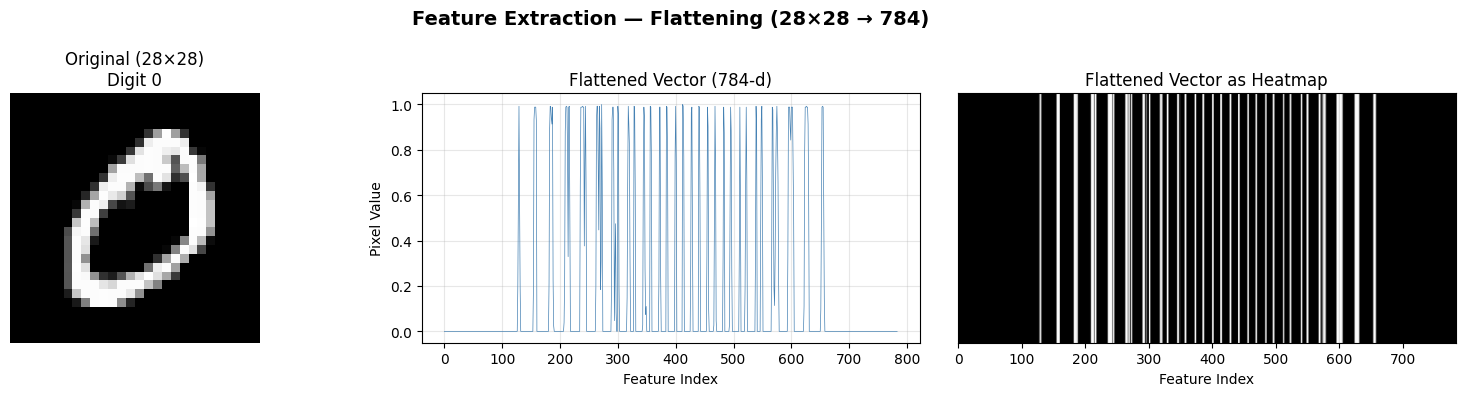

In [11]:
# ── Flattening visualisation ──────────────────────────────────────────
sample_img = X_train_filtered[0]
sample_label = DIGIT_A if y_train_binary[0] == 0 else DIGIT_B

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Original (28×28)\nDigit {sample_label}', fontsize=12)
axes[0].axis('off')

flat = sample_img.reshape(-1) / 255.0
axes[1].plot(flat, color='steelblue', linewidth=0.5)
axes[1].set_title('Flattened Vector (784-d)', fontsize=12)
axes[1].set_xlabel('Feature Index'); axes[1].set_ylabel('Pixel Value')
axes[1].grid(True, alpha=0.3)

axes[2].imshow(flat.reshape(1, -1), cmap='gray', aspect='auto')
axes[2].set_title('Flattened Vector as Heatmap', fontsize=12)
axes[2].set_xlabel('Feature Index'); axes[2].set_yticks([])

plt.suptitle('Feature Extraction — Flattening (28×28 → 784)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Visualise Feature Extraction — Step 2: PCA

C:\Users\a7med\AppData\Local\Temp\ipykernel_35292\523462193.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


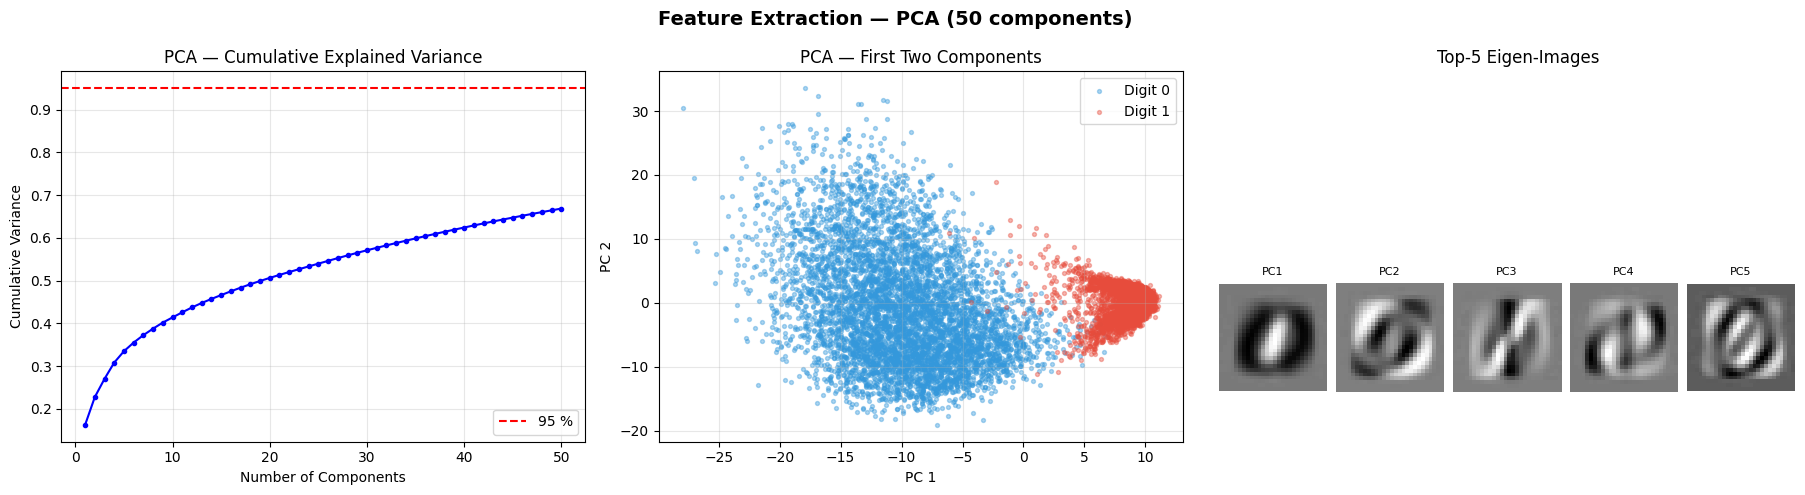

In [12]:
# ── PCA visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'b-o', markersize=3)
axes[0].set_xlabel('Number of Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('PCA — Cumulative Explained Variance', fontsize=12)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95 %')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 2) 2-D scatter of first two principal components
# Use X_train_pca (all training data after PCA) and y_train_binary as labels
scatter_x = X_train_pca[:, 0]
scatter_y = X_train_pca[:, 1]
scatter_labels = y_train_binary  # available in all notebooks at this point
c0 = scatter_labels == 0; c1 = scatter_labels == 1
axes[1].scatter(scatter_x[c0], scatter_y[c0], alpha=0.4, s=8, label=f'Digit {DIGIT_A}', color='#3498db')
axes[1].scatter(scatter_x[c1], scatter_y[c1], alpha=0.4, s=8, label=f'Digit {DIGIT_B}', color='#e74c3c')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
axes[1].set_title('PCA — First Two Components', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 3) Top-5 eigen-images (principal components reshaped back to 28×28)
n_show = min(5, pca.n_components_)
for k in range(n_show):
    ax_inset = fig.add_axes([0.68 + k*0.065, 0.15, 0.06, 0.35])
    ax_inset.imshow(pca.components_[k].reshape(28, 28), cmap='gray')
    ax_inset.set_title(f'PC{k+1}', fontsize=8); ax_inset.axis('off')
axes[2].axis('off')
axes[2].set_title('Top-5 Eigen-Images', fontsize=12)

plt.suptitle(f'Feature Extraction — PCA ({PCA_COMPONENTS} components)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Visualise Feature Extraction — Step 3: HOG (demonstration)

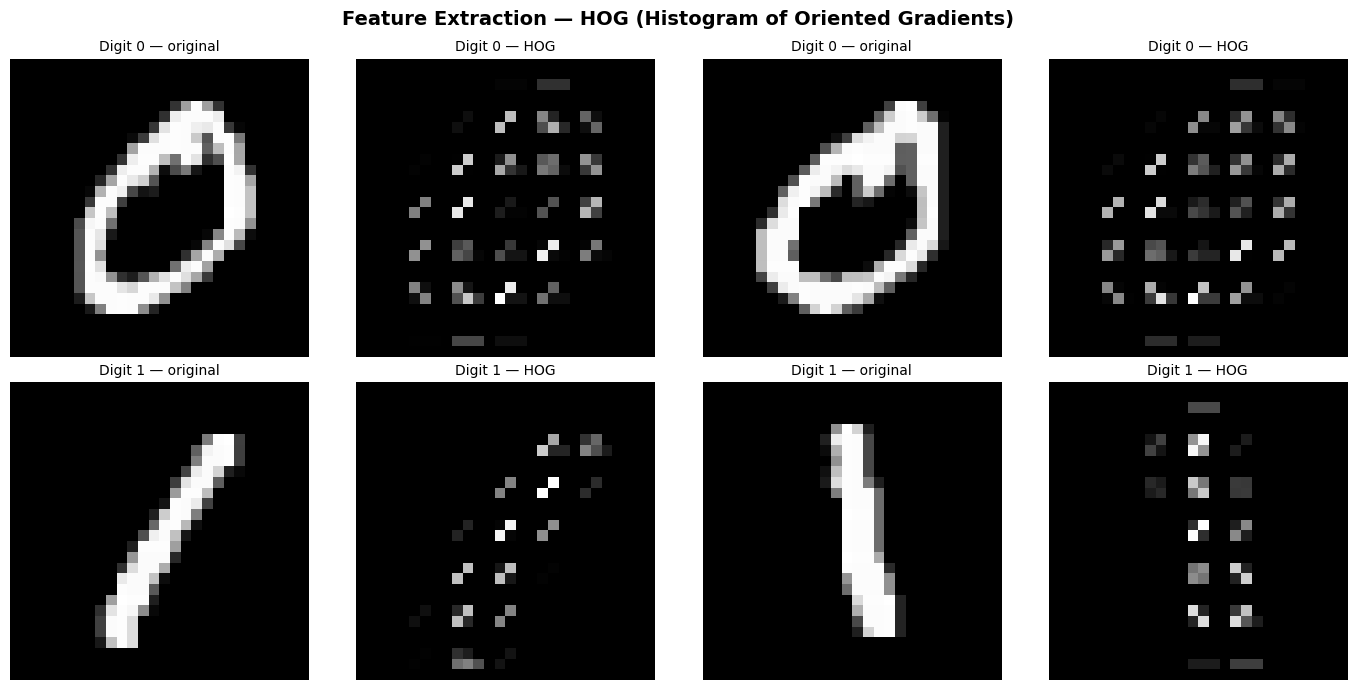

In [13]:
# ── HOG feature visualisation (demonstration) ────────────────────────
# HOG is not used in this pipeline but is shown here for comparison.
try:
    from skimage.feature import hog

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    class0_idx = np.where(y_train_binary == 0)[0]
    class1_idx = np.where(y_train_binary == 1)[0]

    for col, idx in enumerate([class0_idx[0], class0_idx[1]]):
        img = X_train_filtered[idx].astype(np.float64)
        _, hog_img = hog(img, orientations=9, pixels_per_cell=(4, 4),
                         cells_per_block=(2, 2), visualize=True)
        axes[0, col*2].imshow(img, cmap='gray')
        axes[0, col*2].set_title(f'Digit {DIGIT_A} — original', fontsize=10)
        axes[0, col*2].axis('off')
        axes[0, col*2+1].imshow(hog_img, cmap='gray')
        axes[0, col*2+1].set_title(f'Digit {DIGIT_A} — HOG', fontsize=10)
        axes[0, col*2+1].axis('off')

    for col, idx in enumerate([class1_idx[0], class1_idx[1]]):
        img = X_train_filtered[idx].astype(np.float64)
        _, hog_img = hog(img, orientations=9, pixels_per_cell=(4, 4),
                         cells_per_block=(2, 2), visualize=True)
        axes[1, col*2].imshow(img, cmap='gray')
        axes[1, col*2].set_title(f'Digit {DIGIT_B} — original', fontsize=10)
        axes[1, col*2].axis('off')
        axes[1, col*2+1].imshow(hog_img, cmap='gray')
        axes[1, col*2+1].set_title(f'Digit {DIGIT_B} — HOG', fontsize=10)
        axes[1, col*2+1].axis('off')

    plt.suptitle('Feature Extraction — HOG (Histogram of Oriented Gradients)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
except ImportError:
    print("⚠ scikit-image is not installed. Run: pip install scikit-image")

## 10. Train/Validation/Test Split

In [14]:
print("=" * 70)
print("TRAIN/VALIDATION/TEST SPLIT")
print("=" * 70)

# Split training data into train and validation sets
val_ratio = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_pca, y_train_binary, test_size=val_ratio, random_state=42, stratify=y_train_binary
)

# Test set is already separate
X_test = X_test_pca
y_test = y_test_binary

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")
print("✓ Data split complete")

TRAIN/VALIDATION/TEST SPLIT
Training set size: 10430
Validation set size: 2235
Test set size: 2115
✓ Data split complete


## 11. Decision Tree Implementation (From Scratch)

In [15]:
# Implement Decision Tree from scratch
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTreeClassifier:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    
    def gini_impurity(self, y):
        """Calculate Gini impurity"""
        counter = Counter(y)
        impurity = 1.0
        for count in counter.values():
            prob = count / len(y)
            impurity -= prob ** 2
        return impurity
    
    def split_data(self, X, y, feature, threshold):
        """Split data based on feature and threshold"""
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]
    
    def best_split(self, X, y):
        """Find the best split for the data"""
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        
        n_features = X.shape[1]
        
        for feature in range(n_features):
            # Sample a limited number of thresholds instead of checking all unique values
            # This dramatically improves performance for continuous features
            unique_values = np.unique(X[:, feature])
            if len(unique_values) > 10:
                # Sample 10 evenly spaced thresholds
                indices = np.linspace(0, len(unique_values) - 1, 10, dtype=int)
                thresholds = unique_values[indices]
            else:
                thresholds = unique_values
            
            for threshold in thresholds:
                _, _, y_left, y_right = self.split_data(X, y, feature, threshold)
                
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                
                # Calculate weighted Gini impurity
                n = len(y)
                gini = (len(y_left) / n) * self.gini_impurity(y_left) + \
                       (len(y_right) / n) * self.gini_impurity(y_right)
                
                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def build_tree(self, X, y, depth=0):
        """Recursively build the decision tree"""
        n_samples = len(y)
        n_classes = len(np.unique(y))
        
        # Stopping criteria
        if depth >= self.max_depth or n_classes == 1 or n_samples < self.min_samples_split:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
        
        # Find best split
        feature, threshold = self.best_split(X, y)
        
        if feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
        
        # Split data
        X_left, X_right, y_left, y_right = self.split_data(X, y, feature, threshold)
        
        # Recursively build left and right subtrees
        left = self.build_tree(X_left, y_left, depth + 1)
        right = self.build_tree(X_right, y_right, depth + 1)
        
        return Node(feature=feature, threshold=threshold, left=left, right=right)
    
    def fit(self, X, y):
        """Train the decision tree"""
        self.root = self.build_tree(X, y)
    
    def predict_single(self, x, node):
        """Predict class for a single sample"""
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self.predict_single(x, node.left)
        else:
            return self.predict_single(x, node.right)
    
    def predict(self, X):
        """Predict classes for multiple samples"""
        return np.array([self.predict_single(x, self.root) for x in X])

print("✓ Decision Tree Classifier implemented")

✓ Decision Tree Classifier implemented


## 12. Train Decision Tree Model

In [16]:
print("=" * 70)
print(f"TRAINING DECISION TREE MODEL (max_depth={MAX_DEPTH})")
print("=" * 70)

# Initialize and train Decision Tree classifier
dt = DecisionTreeClassifier(max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES_SPLIT)
dt.fit(X_train, y_train)

print("✓ Decision Tree model trained")

TRAINING DECISION TREE MODEL (max_depth=10)
✓ Decision Tree model trained


## 13. Evaluate on Validation Set

In [17]:
print("=" * 70)
print("VALIDATION SET EVALUATION")
print("=" * 70)

# Make predictions on validation set
y_val_pred = dt.predict(X_val)

# Calculate validation accuracy
val_accuracy = np.mean(y_val_pred == y_val)
print(f"\nValidation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

VALIDATION SET EVALUATION

Validation Accuracy: 0.9978 (99.78%)


## 14. Evaluate on Test Set

In [18]:
print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

# Make predictions on test set
y_test_pred = dt.predict(X_test)

# Calculate test accuracy
test_accuracy = np.mean(y_test_pred == y_test)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

TEST SET EVALUATION

Test Accuracy: 0.9976 (99.76%)


## 15. Classification Report

In [19]:
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

# Generate classification report
print(classification_report(y_test, y_test_pred, target_names=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}']))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00       980
     Digit 1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



## 16. Confusion Matrix Visualization

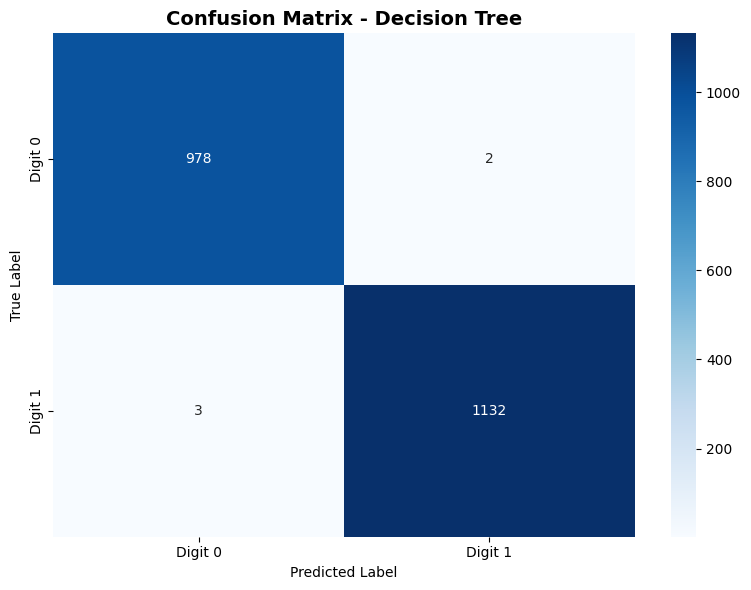

In [20]:
# Generate and visualize confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
            yticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'])
plt.title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Visualise Misclassified Samples

Total misclassified: 5 out of 2115


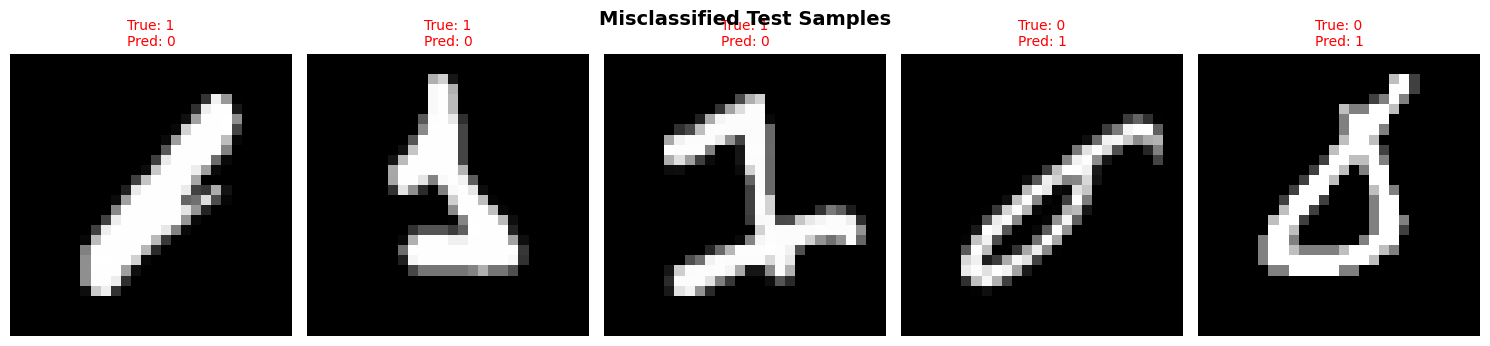

In [21]:
# ── Show wrongly classified test samples ──────────────────────────────
wrong_idx = np.where(y_test_pred != y_test)[0]
n_wrong = len(wrong_idx)
print(f"Total misclassified: {n_wrong} out of {len(y_test)}")

n_show = min(n_wrong, 20)
if n_show == 0:
    print("No misclassified samples — perfect accuracy!")
else:
    cols = min(n_show, 5)
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3.5*rows))
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]
    for k in range(n_show):
        r, c_col = divmod(k, cols)
        idx = wrong_idx[k]
        true_digit = DIGIT_A if y_test[idx] == 0 else DIGIT_B
        pred_digit = DIGIT_A if y_test_pred[idx] == 0 else DIGIT_B
        axes[r, c_col].imshow(X_test_filtered[idx], cmap='gray')
        axes[r, c_col].set_title(f'True: {true_digit}\nPred: {pred_digit}',
                                  fontsize=10, color='red')
        axes[r, c_col].axis('off')
    # hide unused axes
    for k in range(n_show, rows*cols):
        r, c_col = divmod(k, cols)
        axes[r, c_col].axis('off')
    plt.suptitle('Misclassified Test Samples', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

## 17. Final Summary

In [22]:
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"Model: Decision Tree (max_depth={MAX_DEPTH})")
print(f"Binary Classification: Digit {DIGIT_A} vs Digit {DIGIT_B}")
print(f"PCA Components: {PCA_COMPONENTS}")
print(f"\nValidation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n✓ Decision Tree pipeline complete!")

FINAL SUMMARY
Model: Decision Tree (max_depth=10)
Binary Classification: Digit 0 vs Digit 1
PCA Components: 50

Validation Accuracy: 0.9978 (99.78%)
Test Accuracy: 0.9976 (99.76%)

✓ Decision Tree pipeline complete!
